# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [ ]:
# !pip install mat73 h5py

In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt

import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
import kagglehub

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
# Download latest version
path = kagglehub.dataset_download("itshpark/data-driven-prediction-of-battery-cycle")

print("Path to dataset files:", path)

Path to dataset files: /Users/kjsoo/.cache/kagglehub/datasets/itshpark/data-driven-prediction-of-battery-cycle/versions/1


In [4]:
# 데이터 경로 설정 (kagglehub 다운로드 경로 사용)
# .mat 파일이 하위 폴더에 있을 수 있으므로 실제 위치를 탐색
DATA_DIR = next(
    (root for root, _, fnames in os.walk(path) if any(f.endswith('.mat') for f in fnames)),
    path
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_gb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_gb:.1f} GB)")

데이터 경로 : /Users/kjsoo/.cache/kagglehub/datasets/itshpark/data-driven-prediction-of-battery-cycle/versions/1
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [5]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [6]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [7]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [8]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [9]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [10]:
# Batch 1 품질 처리 (Severson et al. 공식 코드 'Load Data.ipynb' 기준)
B1_NOT_REACH_EOL = [8, 10, 12, 13, 22]                         # 80% 용량(0.88Ah)에 도달하지 못한 셀 → 제외
B1_CONTINUED     = {0: 662, 1: 981, 2: 1060, 3: 208, 4: 482}   # 다음 배치로 실험이 이어진 셀 → 수명에 더할 사이클 수

def clean_batch1(df):
    """Batch 1 summary DataFrame 정제"""
    out = df[df['cycle'] > 1]                                  # 첫 사이클은 원본에 측정값이 없어 0으로 채워져 있음
    out = out[~out['cell_id'].isin(B1_NOT_REACH_EOL)].copy()
    out['cycle_life'] += out['cell_id'].map(B1_CONTINUED).fillna(0).astype(int)
    return out.reset_index(drop=True)

_df = extract_summary(batch)   # 원본 백업
df  = clean_batch1(_df)

print(f"DataFrame shape : {_df.shape} → {df.shape}")
print(f"배터리 셀 수    : {_df['cell_id'].nunique()} → {df['cell_id'].nunique()}")
df.head()

DataFrame shape : (38811, 11) → (34300, 11)
배터리 셀 수    : 46 → 41


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,2,1852,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
1,0,3,1852,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
2,0,4,1852,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
3,0,5,1852,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442
4,0,6,1852,3.6C(80%)-3.6C,1.073576,1.073491,0.016623,35.711758,31.961062,29.752932,13.340835


In [11]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,34300.000,34300.000,34300.000,34300.000,34300.000,34300.000,34300.000,34300.000,34300.000,34300.000
mean,21.780,441.940,1000.421,1.045,1.045,0.017,37.319,33.410,30.596,11.569
std,13.898,278.963,441.035,0.048,0.051,0.001,2.508,1.635,1.189,4.783
min,0.000,2.000,534.000,0.880,0.880,0.000,25.938,25.038,23.817,8.897
25%,9.000,211.000,709.000,1.035,1.035,0.017,35.936,32.380,29.881,10.483
50%,23.000,420.000,862.000,1.062,1.062,0.017,37.566,33.447,30.385,11.208
75%,34.000,635.000,1051.000,1.076,1.076,0.017,39.102,34.485,31.180,12.096
max,45.000,1226.000,2237.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [12]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [13]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 41
충전 정책 종류 : 22


## EDA(Basic)

### 1. Cycle Life 분포

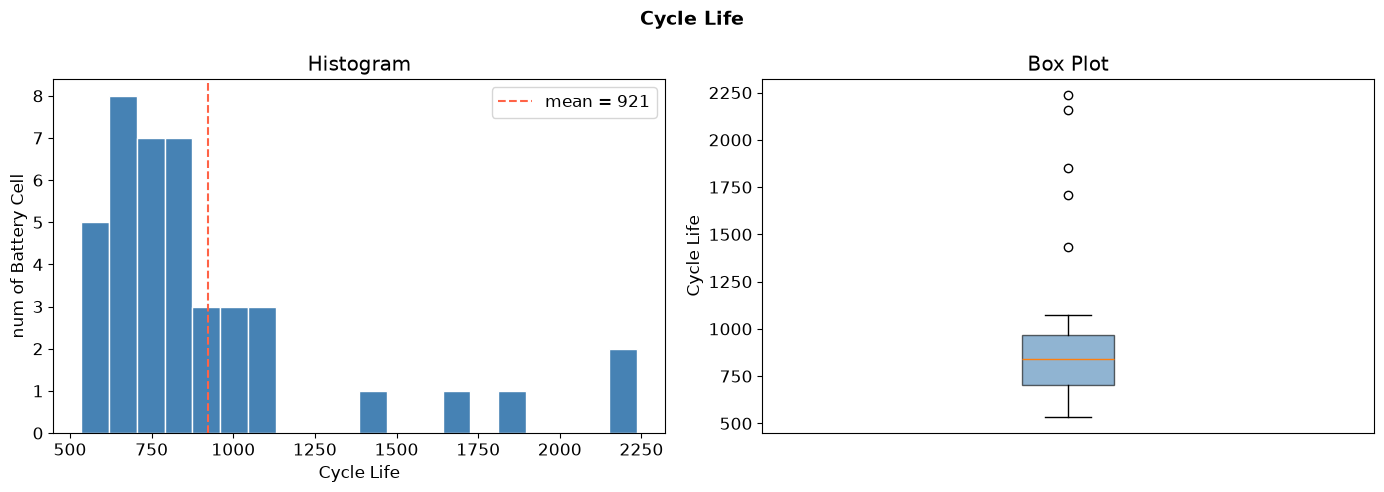

count      41.0
mean      921.3
std       400.8
min       534.0
25%       702.0
50%       842.0
75%       966.0
max      2237.0
Name: cycle_life, dtype: float64


In [14]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 921 사이클, 중앙값 842 사이클 (단명 534 ~ 장수 2237)
- 평균 > 중앙값 (차이 약 80 사이클), 왜도 2.14 -> 오른쪽으로 긴 꼬리를 가진 분포. 소수의 장수 셀이 평균을 끌어올림
- IQR 통해 절반의 배터리가 702 ~ 966 범위에 집중 
- 41개 중 36개가 534 ~ 1074 범위, 나머지 5개는 1434 ~ 2237로 떨어져 있음 (1074 ~ 1434 사이는 비어 있음)

[plot]
- Histogram : 600 ~ 900 구간에 가장 몰려 있고, 1100 이후는 비어 있다가 1400 ~ 2200대에 5개 셀이 흩어져 분포. 정규분포가 아님 
- Box plot : 
    - 상자(IQR) = 702 ~ 966, 폭 264
    - Upper whisker = |75%(966) - 1074| = 108
    - Lower whisker = |25%(702) - min(534)| = 168
    - whisker 밖 이상치 5개 : 1434, 1709, 1852, 2160, 2237
- 이상치 5개는 모두 가장 느린 충전 정책 2종 : `3.6C(80%)-3.6C` 3개, `4C(80%)-4C` 2개 -> 측정 오류가 아니라 충전 조건이 만든 실제 장수 셀이므로 제거 대상이 아님
- 이상치를 제외하면 whisker는 위아래가 비슷함 -> 대부분의 셀은 534 ~ 1074 범위에 비교적 고르게 분포
- 느린 충전 조건의 5개 셀 사이에서도 수명이 1434 ~ 2237로 크게 벌어짐 -> 같은 정책 안에서도 장수 셀의 수명 편차가 큼

[to modeling]
- target이 오른쪽으로 치우쳐 있으므로 로그 변환 검토 (원논문도 log(cycle_life)를 예측)
- 장수 셀이 5개뿐이고 값의 범위가 넓어 예측 난이도가 높고, 이 셀들이 MAPE와 계수 추정에 큰 영향을 줄 수 있음 -> 장수 셀 포함/제외에 따른 성능 차이와 residual 분석 필요
- Hold-out 분할 시 장수 셀 5개가 한쪽에 몰리지 않도록 수명 구간을 고려해 나눌 것
- Classification 선택 시 : 550 사이클 미만인 셀이 1개(534)뿐이라 Batch 1만으로는 단수명 클래스를 학습하기 어려움

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

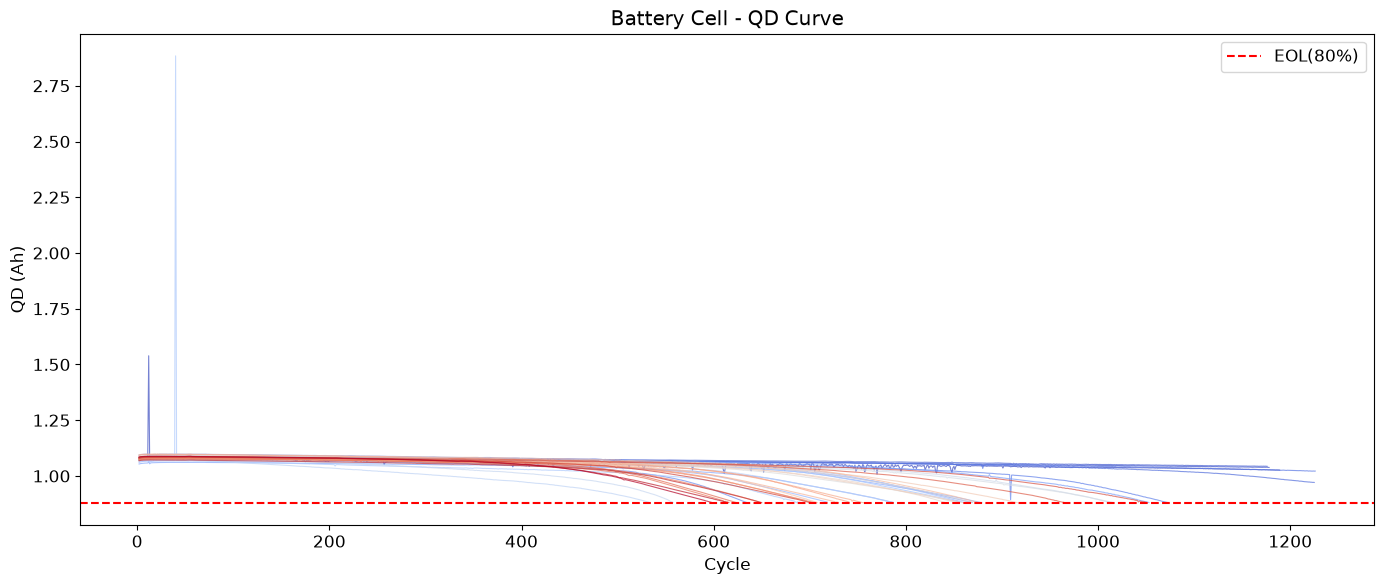

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

# nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
## 공칭 용량 1.1Ah의 80%
ax.axhline(y=0.88, # * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0795 Ah
필터 범위          : 0.8636 ~ 1.2954 Ah
제거된 행 수       : 2 (0.01%)


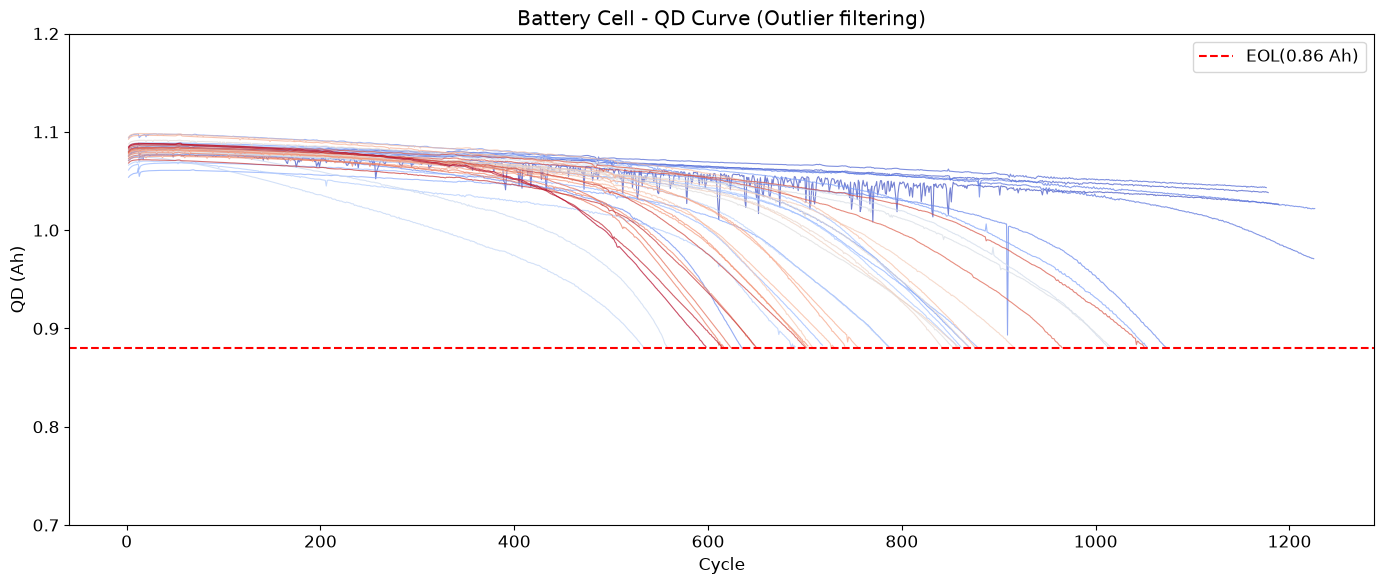

In [ ]:
# # Outlier 필터링 후 열화 곡선 

# # 1. 정상 용량 범위 정의
# nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
# lower   = nominal * 0.80 # cycle 2로 사전에 우리가 걸러서 필요 x
# upper   = nominal * 1.20

# print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
# print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# # 2. 필터링
# df_clean = df[df['QD'].between(lower, upper)].copy()
# print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# # 3. 시각화
# fig, ax = plt.subplots(figsize=(14, 6))

# cell_ids = df_clean['cell_id'].unique()
# colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

# for i, cid in enumerate(cell_ids):
#     sub = df_clean[df_clean['cell_id'] == cid]
#     ax.plot(sub['cycle'], sub['QD'],
#             color=colors[i], linewidth=0.8, alpha=0.7)

# ax.axhline(y=0.88, color='red', linestyle='--', # 동일하게 0.88 Ah 기준
#            linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
# ax.set_xlabel('Cycle')
# ax.set_ylabel('QD (Ah)')
# ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
# ax.set_ylim(0.7, 1.2)
# ax.legend()
# plt.tight_layout()
# plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 달느 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

초기 방전 용량(중앙값) : 1.0795 Ah
필터 범위              : 0.8636 ~ 1.2954 Ah
제거된 행 수           : 2 (0.01%)


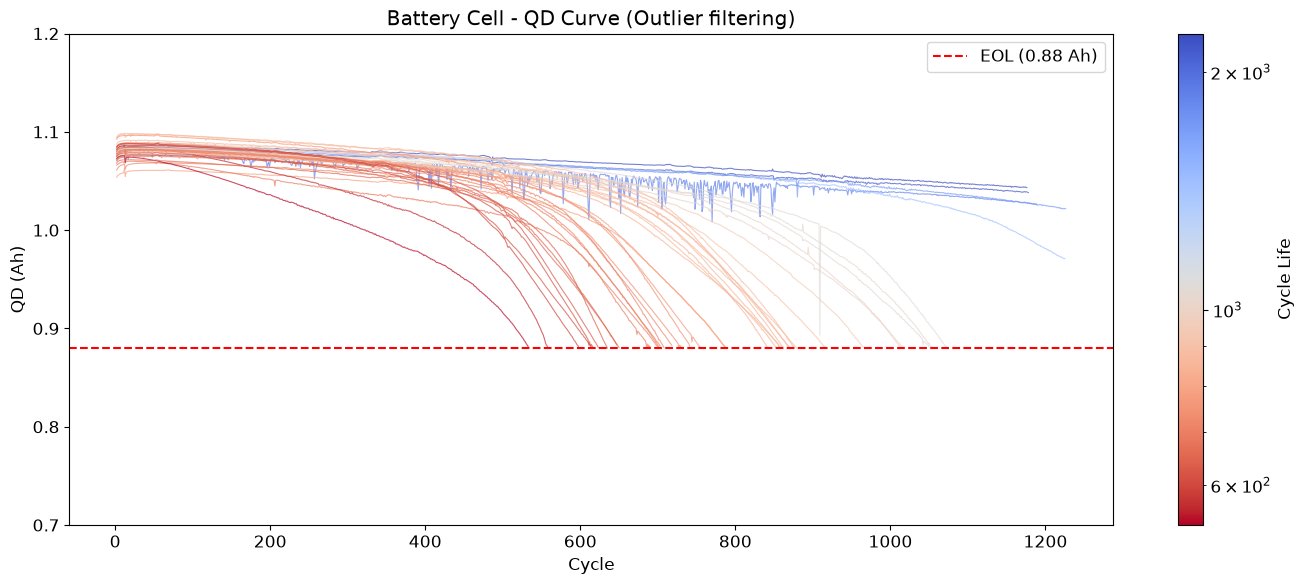

In [17]:
# Outlier 필터링 후 열화 곡선 
from matplotlib.colors import LogNorm

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"초기 방전 용량(중앙값) : {nominal:.4f} Ah")
print(f"필터 범위              : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수           : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화 (색 = cycle life, 파랑: 장수 / 빨강: 단명)
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
life = df_clean.drop_duplicates('cell_id').set_index('cell_id')['cycle_life']
norm = LogNorm(life.min(), life.max())

for cid in cell_ids:
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=cm.coolwarm_r(norm(life[cid])), linewidth=0.8, alpha=0.7)

ax.axhline(y=0.88, color='red', linestyle='--',
           linewidth=1.5, label='EOL (0.88 Ah)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='coolwarm_r'), ax=ax, label='Cycle Life')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()


[plot] - 색 = cycle life (파랑 : 장수 / 빨강 : 단명, 로그 스케일)
- cycle 2 ~ 100 : 빨강과 파랑이 한 덩어리로 겹쳐 있어 색으로 구분되지 않음
    - 단수명 셀(700 미만, 10개)과 장수명 셀(1000 이상, 10개)의 평균 용량 차이 : cycle 2에서 0.001 Ah, cycle 100에서 0.006 Ah
    - 같은 시점 셀 간 용량 범위는 0.04 Ah -> 수명에 따른 차이가 셀 간 편차에 묻힘
    - 초기 용량이 가장 높은 5개 셀의 수명은 757 ~ 876으로 중간 수준, 최장수 그룹인 셀 0(수명 1852)은 초기 용량이 하위 5번째 -> 초기 용량이 높다고 오래 가지 않음
- cycle 100 ~ 400 : 빨간 곡선부터 아래로 벌어지기 시작하지만 색이 아직 섞여 있음
    - 용량과 수명의 순위 상관(Spearman) : cycle 2에서 0.09, cycle 100에서 0.33, cycle 200에서 0.43
- cycle 400 ~ : 색 순서대로 정렬됨. 빨강 -> 주황 -> 회색 -> 파랑 순으로 EOL에 도달
    - 순위 상관 : cycle 400에서 0.81, cycle 500에서 0.91 -> 용량이 수명을 반영하는 것은 열화가 이미 진행된 뒤
- 곡선 모양은 수명과 무관하게 비슷함 : 평탄 구간 뒤에 급락(knee)
    - 용량이 1.0 Ah 아래로 내려간 뒤 EOL까지 걸리는 사이클 : 전체 91 ~ 211, 단수명 셀 114 / 장수명 셀 169 (중앙값)
    - 수명 차이는 급락 구간의 길이가 아니라 급락이 시작되는 시점에서 생김
- 측정 노이즈 : 셀 0(수명 1852)은 cycle 257 ~ 851 구간에 아래로 튀는 값이 57회, 셀 5(수명 1074)는 cycle 909에서 0.89 Ah까지 한 번 튐. 필터 범위 안이라 제거되지 않고 남아 있음

[to modeling]
- 초기 100 사이클의 용량(QD) 수준은 수명 순위를 거의 설명하지 못함 (순위 상관 0.33 이하) -> QD 값 자체는 주 피처로 부적합
- 수명을 결정하는 것은 knee의 시작 시점인데 초기 100 사이클에는 아직 나타나지 않음 -> 용량 곡선에 드러나지 않는 초기 신호가 필요 -> 전압 곡선의 변화 ΔQ(V) 확인
- 사이클 단위 값에 튀는 측정값이 섞여 있으므로, 단일 사이클 값보다 구간 통계(중앙값, 기울기 등)나 평활화한 값을 피처로 사용


### 3. 내부 저항(IR) 변화 - 열화 지표

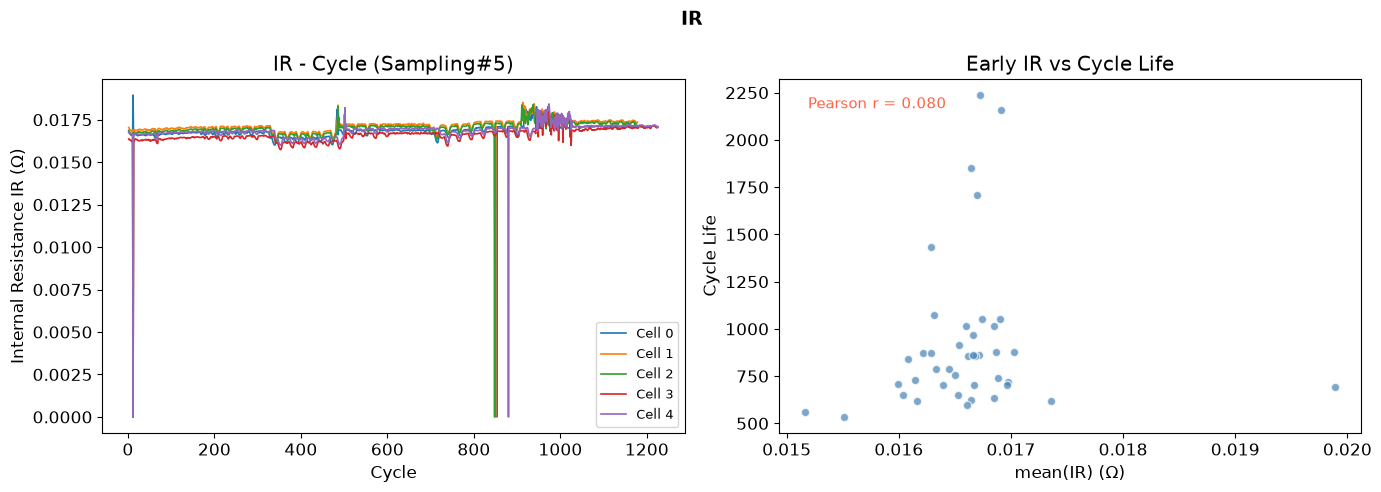

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

In [ ]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

In [ ]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.